# Convolutional Neural Networks (CNN)

## Feature extraction and classification using CNN
In this tutorial, we use CIFAR images dataset to train a CNN network, using Tensorflow and
Keras prebuilt functions (see the file UB_AI_Lecture8_CNN_Example.ipynb).

In [1]:
# Import Tensorflow and Keras
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [2]:
# Download and prepare the CIFAR10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values (between 0 and 255) to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


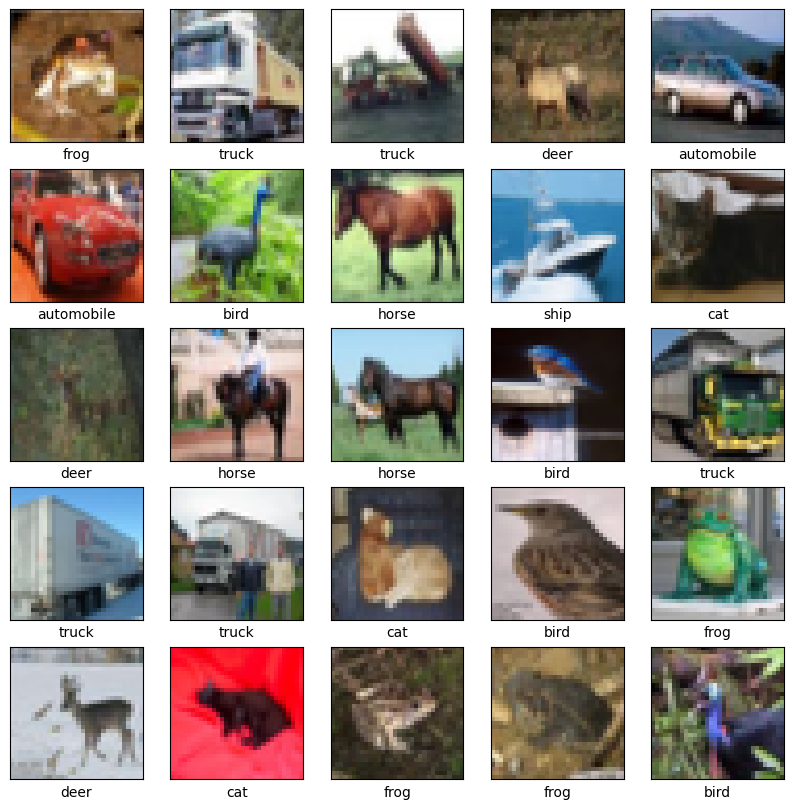

In [3]:
# Verify the data
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [4]:
""" Create the CNN network (The feature extraction part)
 using conv and maxpooling layers with a Relu activation function
 """
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Display the feature extractor architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Add the classifier part(Dense/DNN layers)
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [7]:
# Dispaly the full CNN network's architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile the model (To check any inadequacy in the architecture)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [9]:
# Train the model on the CIFAR10 dataset
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.3402 - loss: 1.7845 - val_accuracy: 0.5308 - val_loss: 1.2992
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 45ms/step - accuracy: 0.5703 - loss: 1.2109 - val_accuracy: 0.5920 - val_loss: 1.1534
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6367 - loss: 1.0323 - val_accuracy: 0.6385 - val_loss: 1.0281
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.6734 - loss: 0.9321 - val_accuracy: 0.6508 - val_loss: 1.0205
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6950 - loss: 0.8636 - val_accuracy: 0.6756 - val_loss: 0.9363
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.7208 - loss: 0.7983 - val_accuracy: 0.6956 - val_loss: 0.9051
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.7343 - loss: 0.7604 - val_accuracy: 0.6810 - val_loss: 0.9198
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7522 -

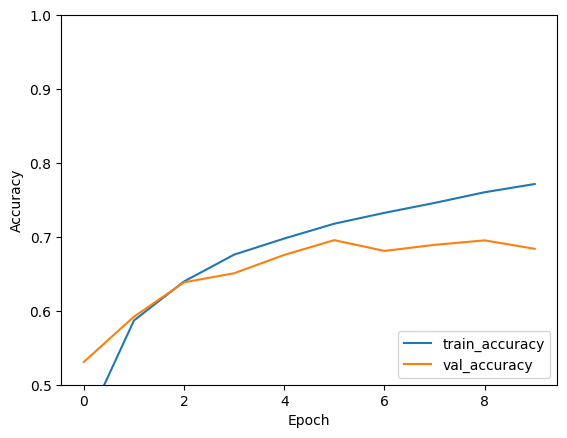

In [10]:
# Visualise the accuracy curve during training
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')



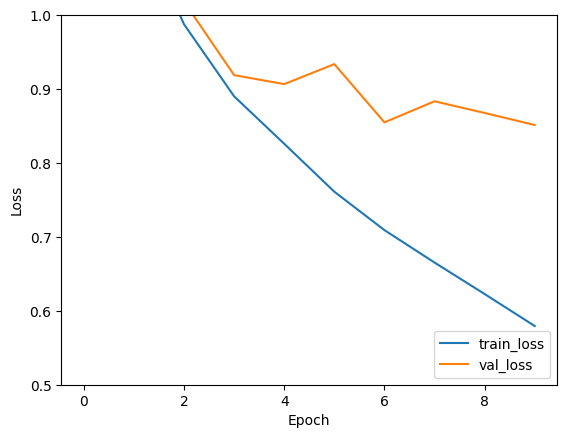

In [ ]:
# Visualise the loss curve during training
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')


In [11]:
# Evaluate the model on the validation set
val_loss, val_acc = model.evaluate(test_images,  test_labels, verbose=2)
print('Validation loss = ','{0:.2f}'.format(val_loss*100),'%')
print('val accuracy = ','{0:.2f}'.format(val_acc*100),'%')


313/313 - 4s - 11ms/step - accuracy: 0.6839 - loss: 0.9299
Validation loss =  92.99 %
val accuracy =  68.39 %


In [12]:
# Predict the class labels on the test set
y_pred = model.predict(test_images)
y_pred
import numpy as np
pred_labels = np.argmax(y_pred, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [13]:

# Claculate the accuracy and generate the classification report
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

test_accuracy = accuracy_score(test_labels, pred_labels)
print('Accuracy on the test set: %.2f' % (test_accuracy*100))
print(classification_report(test_labels,pred_labels))


Accuracy on the test set: 68.39
              precision    recall  f1-score   support

           0       0.79      0.69      0.74      1000
           1       0.84      0.76      0.80      1000
           2       0.74      0.40      0.52      1000
           3       0.46      0.53      0.49      1000
           4       0.63      0.66      0.64      1000
           5       0.53      0.63      0.58      1000
           6       0.74      0.75      0.74      1000
           7       0.73      0.77      0.75      1000
           8       0.77      0.80      0.78      1000
           9       0.71      0.85      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



# Exercise 2: Multi-class classification using CNN

In this exercise, we aim at designing and training a convolutional neural network (CNN) to
classify MNIST dataset images that contain handwritten digits (from 0 to 9).

### 1. Setup

In [20]:
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

### 2. Data preparation

In [18]:
MNIST = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [28]:
# What is MNIST? A Tuple
type(MNIST)

tuple

In [27]:
# Whats the size of the main tuple?
len(MNIST)

2

In [29]:
# Whats the type of each value of the main tuple? A "sub-tuple"
type(MNIST[0]), type(MNIST[1])

(tuple, tuple)

In [30]:
# Whats the size of each "subtuple"?
len(MNIST[0]), len(MNIST[1])

(2, 2)

In [39]:
# Naiming the tuples
(X_train, y_train), (X_test, y_test) = MNIST

In [40]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


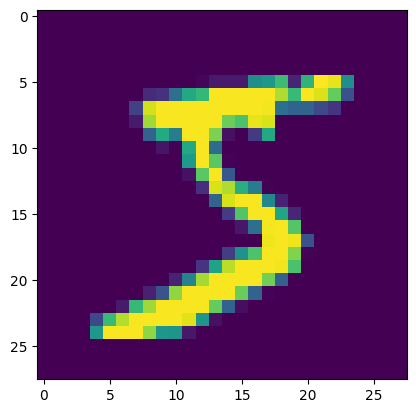

In [41]:
plt.imshow(X_train[0])

### 3.  Feature processing

In [42]:
# Convert to float and normalize
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

In [43]:
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

In [44]:
print("X_train shape:", X_train.shape)
print(X_train.shape[0], "train samples")
print(X_test.shape[0], "test samples")

X_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


### 4. Build the CNN network

In [17]:
number_class = 10
input_shape = (28,28,1)

In [46]:
model = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),

    layers.Dense(number_class, activation="softmax")
])

In [47]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

The input images are first normalized and reshaped to include a channel dimension.
The CNN consists of two convolutional layers with ReLU activation, each followed by max-pooling, then a flatten layer, dropout for regularization, and a softmax output layer for multi-class classification.

### 5. Training

In [49]:
number_classes = 10

# cat -> categorical
y_train_cat = keras.utils.to_categorical(y_train, number_classes)
y_test_cat  = keras.utils.to_categorical(y_test, number_classes)

In [50]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [51]:
history = model.fit(
    X_train, y_train_cat,
    batch_size=128,
    epochs=15,
    validation_split=0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 50s 113ms/step - accuracy: 0.7633 - loss: 0.7633 - val_accuracy: 0.9775 - val_loss: 0.0833
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 88s 128ms/step - accuracy: 0.9629 - loss: 0.1227 - val_accuracy: 0.9860 - val_loss: 0.0557
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 69s 97ms/step - accuracy: 0.9729 - loss: 0.0867 - val_accuracy: 0.9865 - val_loss: 0.0482
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.9780 - loss: 0.0723 - val_accuracy: 0.9887 - val_loss: 0.0417
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9808 - loss: 0.0655 - val_accuracy: 0.9878 - val_loss: 0.0398
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9822 - loss: 0.0577 - val_accuracy: 0.9898 - val_loss: 0.0351
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9850 - loss: 0.0485 - val_accuracy: 0.9888 - val_loss: 0.0372
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9853 - loss: 0.0442 

### 6. Evaluate the model after learning

In [52]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.026173578575253487
Test accuracy: 0.9908999800682068


In [55]:
y_pred_probs = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


In [56]:
y_pred = np.argmax(y_pred_probs, axis=1)

In [57]:
y_true = np.argmax(y_test_cat, axis=1)

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 976    0    1    0    0    0    0    2    1    0]
 [   0 1134    1    0    0    0    0    0    0    0]
 [   2    1 1024    0    1    0    1    2    1    0]
 [   0    1    3 1000    0    4    0    1    1    0]
 [   0    0    0    0  977    0    2    0    1    2]
 [   1    0    0    4    0  885    1    1    0    0]
 [   2    2    1    0    1    3  947    0    2    0]
 [   0    3    7    1    0    1    0 1014    1    1]
 [   2    0    2    0    1    0    0    1  965    3]
 [   0    3    0    0    7    5    0    5    2  987]]


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



# Exercise 3: Feature extraction and class prediction for image using a pretrained CNN model (VGG16)

The goal of this exercise is to leverage pretrained CNN models, such VGG16, to carry out: firstly
feature extraction and then class prediction. VGG16 is a pretrained model, i.e. that was learnt by
training over a huge dataset, e.g. ImageNet. This implies that is ready to be used, without any
further training. In this exercise, we aim at discovering how the feature extractor and the classifier
parts contained in this model can be re-used, by applying it to a sample image.

In [60]:
import keras
import numpy as np
import matplotlib.pyplot as plt

from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input, decode_predictions

In [61]:
feature_extractor = VGG16(weights="imagenet", include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [62]:
feature_extractor.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
from google.colab import files
uploaded = files.upload()

Saving elephant.jpg to elephant.jpg


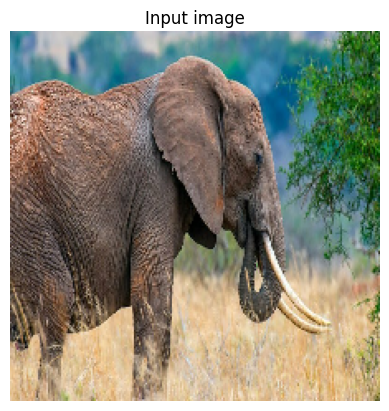

In [65]:
import keras
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]  # gets uploaded file name
img = keras.utils.load_img(img_path, target_size=(224, 224))

plt.imshow(img)
plt.title("Input image")
plt.axis("off")
plt.show()

In [67]:
x = keras.utils.img_to_array(img)     # (224, 224, 3)
x = np.expand_dims(x, axis=0)           # (1, 224, 224, 3)  batch size = 1
x = preprocess_input(x)                # VGG16 preprocessing

In [68]:
features = feature_extractor.predict(x)
print("Extracted features shape:", features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Extracted features shape: (1, 7, 7, 512)


2D features shape: (49, 512)


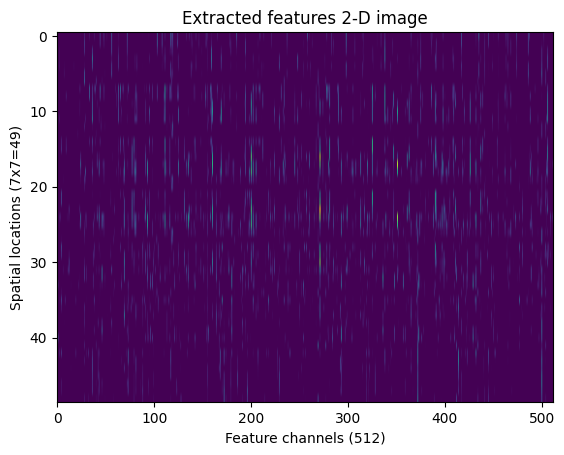

In [69]:
features_2d = features.reshape(features.shape[1] * features.shape[2], features.shape[3])
print("2D features shape:", features_2d.shape)  # (49, 512)

plt.imshow(features_2d, aspect="auto")
plt.title("Extracted features 2-D image")
plt.xlabel("Feature channels (512)")
plt.ylabel("Spatial locations (7x7=49)")
plt.show()


In [70]:
pretrained_model = VGG16(weights="imagenet", include_top=True)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


In [71]:
pretrained_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
y_pred = pretrained_model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [73]:
top_k = 3
decoded = decode_predictions(y_pred, top=top_k)[0]

print("Top predictions:")
for class_id, class_name, prob in decoded:
    print(f"- {class_name}: {prob:.4f}")

best_class_id, best_class_name, best_prob = decoded[0]
print("\nMost likely class:", best_class_name)
print("Max probability:", best_prob)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Top predictions:
- African_elephant: 0.6828
- tusker: 0.2881
- Indian_elephant: 0.0291

Most likely class: African_elephant
Max probability: 0.6828056
